## Positional Encodings -  enable LLM to understand the order and relationship between tokens , ensuring more acurate and context aware predictions

1. the cat sat on the mat
2. on the mat the cat sat


In the embedding layer, the same tokenId gets mapped to the same vector representation, regardless of where the tokenId is positioned in input sequence.

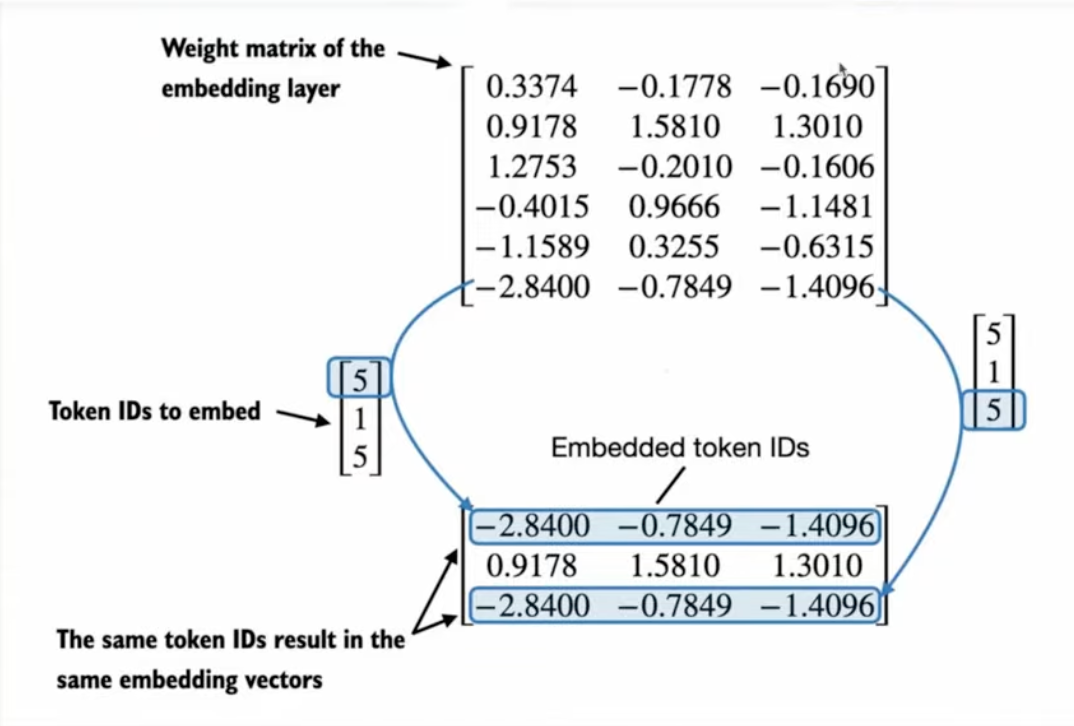

We need to inject additional positional information. Two types of positional embeddings

1. Absolute Positional Embeddings
2. Relative Positional Embeddings

### Absolute Positional Embeddings

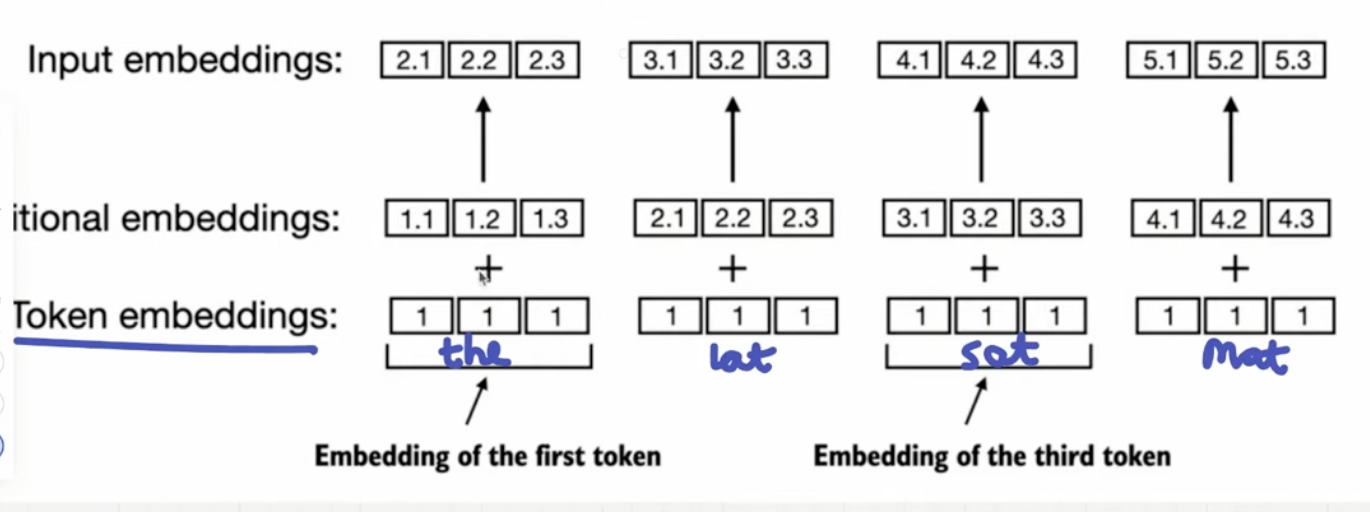

In [4]:
## For each position in input sequence, a unique embedding is 
## added to the tokens embedding to convey its exact position

## 1. The positional vectors ahev same dimension as original token embeddings


### Relative Positional Embeddings

1. The emphasis is on the relative position or distance between tokens. 
2. The model learns the relationships in terms of "how far apart" rather than at which exact position.
3. Advantage - Model can generalize better to sequence of varying lengths even if it has not seen susch lengths during training

## Which one to choose

Absolute :- Suitable when fixed order of tokens in crucial such as sequence generation

Ex- GPT and original transformer used this


Relative :- Suitablefor tasks like language modeling over long sequences where the same phrase can appear in different parts of the sequence

## how are these absolute positional embeddings generated

1. OpenAI's GPT models uses absolute positional embeddings that are optimized suring the training process. This optimization is part of the model training itself

2. Original Transformer paper uses Sinusoidal absolute positional encodings

In [12]:
import torch
vocab_size = 50257
output_dim = 256

In [14]:
batch_size = 8
context_size = 4

## Embeddings (vocab_size * embedding_size)
token_embedding_layer = torch.nn.Embedding(vocab_size,output_dim)
tokenids = torch.tensor([ 
                            [40,367,2885,1464],
                            [1807,3619,402,271],
                            [10899, 2138, 257, 7026],
                            [15632, 438, 2016, 257],
                            [922, 5981, 1576, 438],
                            [568, 340, 373, 645],
                            [149, 5975, 284, 502],
                            [284,3285, 326, 11]
                        ]
                    )

embeddings = token_embedding_layer(tokenids)
print(embeddings.shape)


## Positional Embeddings (context_size * embedding_size)
## Same matrix Can be applied for every input of context size in batch
pos_embedding_layer = torch.nn.Embedding(context_size,output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_size))
print(pos_embeddings.shape)

torch.Size([8, 4, 256])
torch.Size([4, 256])


Therefore, 

1. Normal Embeddings - batch_size * context_size * embedding_size

2. Postional Embeddings - context_size * embedding_size

In [18]:
## final embeddings
## Boroadcast happens for positional embedings to match the shape embeddings
final_embeddings = embeddings+pos_embeddings
print(final_embeddings.shape)

torch.Size([8, 4, 256])
